<a href="https://colab.research.google.com/github/Ethnica16/carechain-predict/blob/main/medsupply_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MedSupplyAI – Predictive Hospital Supply Chain Analytics

This notebook demonstrates the machine learning pipeline behind the MedSupplyAI prototype.  
It covers:
- Synthetic data generation representing realistic hospital supply usage
- Exploratory data analysis (EDA)
- Feature engineering
- Demand forecasting using Random Forest and XGBoost
- Model evaluation and comparison
- Actionable inventory insights

**Goal:** Predict weekly demand for critical medical supplies to reduce stockouts, overstocking, and expired inventory.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Synthetic Data Generation

We simulate 2 years of weekly supply usage across 6 hospital departments and 8 supply categories.  
Usage patterns reflect realistic seasonality (flu season, summer slowdowns) and department-level variation.

In [2]:
# --- Configuration ---
N_WEEKS = 104  # 2 years
START_DATE = '2022-01-01'

DEPARTMENTS = ['ICU', 'ER', 'Surgery', 'Oncology', 'Pediatrics', 'General Ward']
SUPPLIES = ['Surgical Gloves', 'IV Bags', 'Syringes', 'Masks',
            'Catheters', 'Bandages', 'Ventilator Filters', 'Blood Tubes']

# Base weekly demand per supply (units)
BASE_DEMAND = {
    'Surgical Gloves': 800, 'IV Bags': 300, 'Syringes': 600,
    'Masks': 1000, 'Catheters': 150, 'Bandages': 400,
    'Ventilator Filters': 80, 'Blood Tubes': 250
}

# Department usage multipliers
DEPT_MULTIPLIER = {
    'ICU': 1.4, 'ER': 1.3, 'Surgery': 1.5,
    'Oncology': 1.1, 'Pediatrics': 0.8, 'General Ward': 0.9
}

dates = pd.date_range(START_DATE, periods=N_WEEKS, freq='W')
records = []

for dept in DEPARTMENTS:
    for supply in SUPPLIES:
        base = BASE_DEMAND[supply] * DEPT_MULTIPLIER[dept]
        for i, date in enumerate(dates):
            # Seasonality: flu season peaks in winter (weeks 0-8 and 45-52)
            week_of_year = date.isocalendar().week
            seasonal_factor = 1.0
            if week_of_year <= 8 or week_of_year >= 45:
                seasonal_factor = 1.25  # Winter surge
            elif 22 <= week_of_year <= 35:
                seasonal_factor = 0.85  # Summer slowdown

            # Trend: slight growth over time
            trend_factor = 1 + (i / N_WEEKS) * 0.1

            # Random noise
            noise = np.random.normal(1.0, 0.08)

            demand = int(base * seasonal_factor * trend_factor * noise)

            # Stock on hand (simulate occasional shortages)
            stock_on_hand = int(demand * np.random.uniform(0.7, 1.5))
            lead_time_days = np.random.choice([3, 5, 7, 10, 14])
            unit_cost = round(np.random.uniform(0.5, 45.0), 2)
            expiry_risk = 1 if stock_on_hand > demand * 1.3 else 0
            stockout = 1 if stock_on_hand < demand * 0.85 else 0

            records.append({
                'date': date,
                'department': dept,
                'supply_item': supply,
                'week_of_year': week_of_year,
                'month': date.month,
                'quarter': date.quarter,
                'year': date.year,
                'demand_units': demand,
                'stock_on_hand': stock_on_hand,
                'lead_time_days': lead_time_days,
                'unit_cost_usd': unit_cost,
                'expiry_risk_flag': expiry_risk,
                'stockout_flag': stockout
            })

df = pd.DataFrame(records)
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.date.min().date()} to {df.date.max().date()}')
df.head()

Dataset shape: (4992, 13)
Date range: 2022-01-02 to 2023-12-24


,date,department,supply_item,week_of_year,month,quarter,year,demand_units,stock_on_hand,lead_time_days,unit_cost_usd,expiry_risk_flag,stockout_flag
0,2022-01-02,ICU,Surgical Gloves,52,1,1,2022,1455,1870,14,27.06,0,0
1,2022-01-09,ICU,Surgical Gloves,1,1,1,2022,1385,1463,7,20.94,0,0
2,2022-01-16,ICU,Surgical Gloves,2,1,1,2022,1303,1590,14,43.66,0,0
3,2022-01-23,ICU,Surgical Gloves,3,1,1,2022,1357,1853,5,8.59,1,0
4,2022-01-30,ICU,Surgical Gloves,4,1,1,2022,1341,1501,10,1.53,0,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Overview ===')
print(f'Total records: {len(df):,}')
print(f'Departments: {df.department.nunique()}')
print(f'Supply items: {df.supply_item.nunique()}')
print(f'\nStockout rate: {df.stockout_flag.mean():.1%}')
print(f'Expiry risk rate: {df.expiry_risk_flag.mean():.1%}')
print(f'\nMissing values:\n{df.isnull().sum()}')

=== Dataset Overview ===
Total records: 4,992
Departments: 6
Supply items: 8

Stockout rate: 19.1%
Expiry risk rate: 23.9%

Missing values:
date                0
department          0
supply_item         0
week_of_year        0
month               0
quarter             0
year                0
demand_units        0
stock_on_hand       0
lead_time_days      0
unit_cost_usd       0
expiry_risk_flag    0
stockout_flag       0
dtype: int64


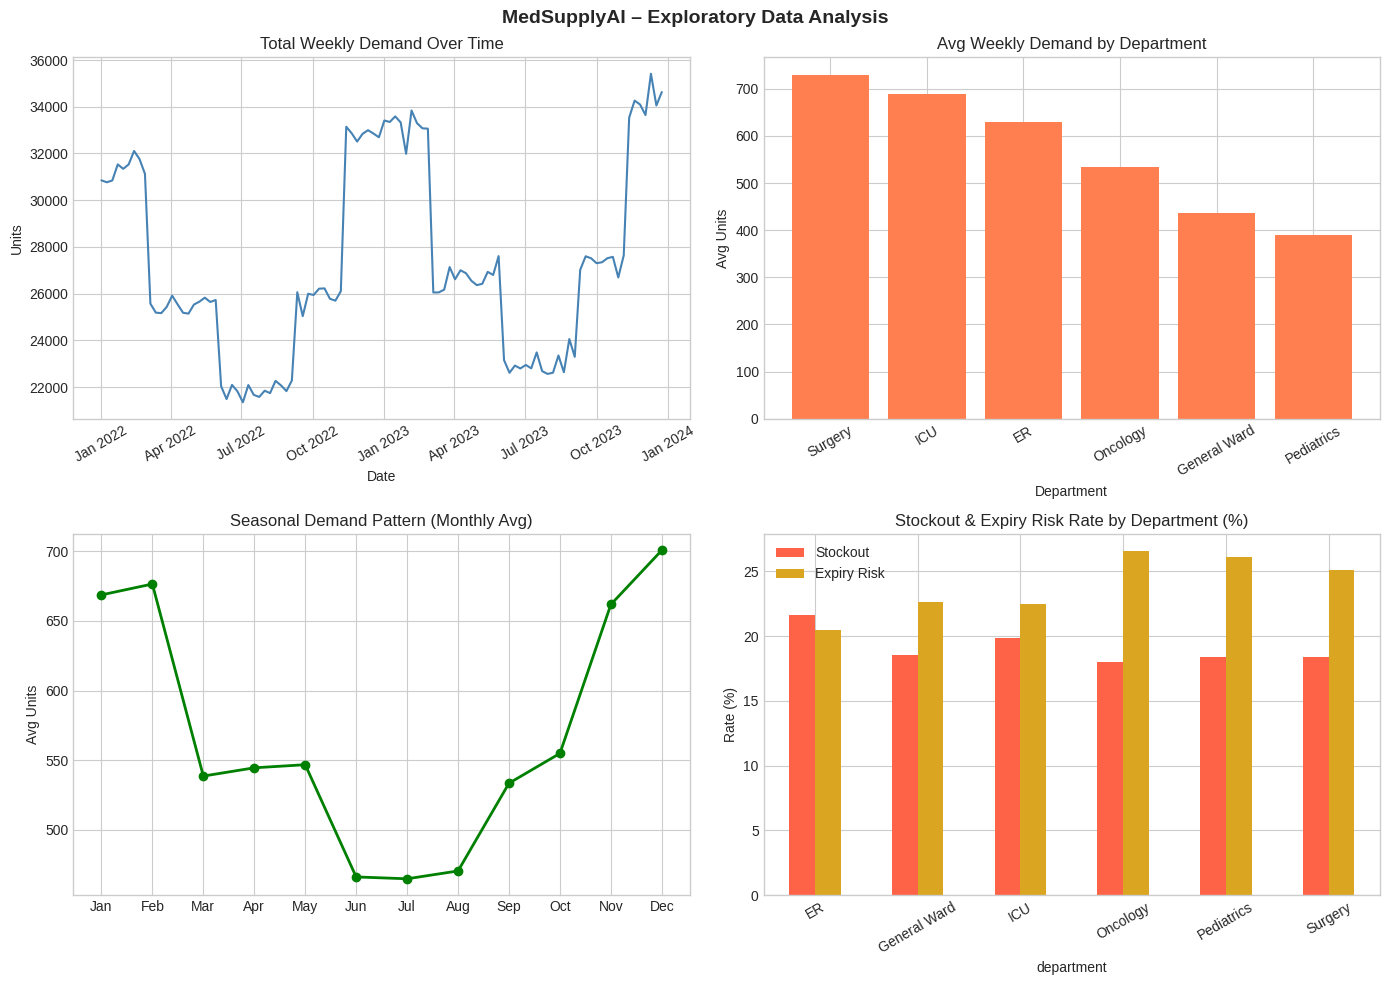

EDA chart saved.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MedSupplyAI – Exploratory Data Analysis', fontsize=14, fontweight='bold')

# 1. Weekly demand over time (aggregated)
weekly_total = df.groupby('date')['demand_units'].sum()
axes[0, 0].plot(weekly_total.index, weekly_total.values, color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Total Weekly Demand Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Units')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30)

# 2. Average demand by department
dept_demand = df.groupby('department')['demand_units'].mean().sort_values(ascending=False)
axes[0, 1].bar(dept_demand.index, dept_demand.values, color='coral')
axes[0, 1].set_title('Avg Weekly Demand by Department')
axes[0, 1].set_xlabel('Department')
axes[0, 1].set_ylabel('Avg Units')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=30)

# 3. Seasonal demand pattern
monthly_avg = df.groupby('month')['demand_units'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1, 0].plot(range(1, 13), monthly_avg.values, marker='o', color='green', linewidth=2)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names)
axes[1, 0].set_title('Seasonal Demand Pattern (Monthly Avg)')
axes[1, 0].set_ylabel('Avg Units')

# 4. Stockout & expiry flags by department
risk_df = df.groupby('department')[['stockout_flag','expiry_risk_flag']].mean() * 100
risk_df.plot(kind='bar', ax=axes[1, 1], color=['tomato', 'goldenrod'])
axes[1, 1].set_title('Stockout & Expiry Risk Rate by Department (%)')
axes[1, 1].set_ylabel('Rate (%)')
axes[1, 1].legend(['Stockout', 'Expiry Risk'])
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved.')

## 4. Feature Engineering

We create lag features (past demand), rolling averages, and encode categorical variables.  
These are the key inputs that allow the model to learn temporal patterns.

In [5]:
# Sort for time-series integrity
df = df.sort_values(['department', 'supply_item', 'date']).reset_index(drop=True)

# Lag features: demand from 1, 2, and 4 weeks ago
for lag in [1, 2, 4]:
    df[f'demand_lag_{lag}w'] = df.groupby(['department', 'supply_item'])['demand_units'].shift(lag)

# Rolling averages: 4-week and 8-week
df['demand_rolling_4w'] = (
    df.groupby(['department', 'supply_item'])['demand_units']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)
df['demand_rolling_8w'] = (
    df.groupby(['department', 'supply_item'])['demand_units']
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

# Encode categoricals
le_dept = LabelEncoder()
le_supply = LabelEncoder()
df['dept_encoded'] = le_dept.fit_transform(df['department'])
df['supply_encoded'] = le_supply.fit_transform(df['supply_item'])

# Drop rows with NaN from lagging (first few weeks per group)
df_model = df.dropna().reset_index(drop=True)
print(f'Modeling dataset shape (after lag dropna): {df_model.shape}')
df_model[['department', 'supply_item', 'demand_units',
           'demand_lag_1w', 'demand_rolling_4w']].head()

Modeling dataset shape (after lag dropna): (4608, 20)


,department,supply_item,demand_units,demand_lag_1w,demand_rolling_4w
0,ER,Bandages,599,607.0,640.75
1,ER,Bandages,516,599.0,626.25
2,ER,Bandages,563,516.0,596.25
3,ER,Bandages,520,563.0,571.25
4,ER,Bandages,556,520.0,549.50


## 5. Model Training

We train and compare two models:
- **Random Forest:** ensemble of decision trees, robust to noise
- **XGBoost:** gradient boosting, typically higher accuracy on tabular data

We use a time-aware train/test split (no data leakage — test set is always the most recent weeks).

In [6]:
FEATURES = [
    'dept_encoded', 'supply_encoded',
    'week_of_year', 'month', 'quarter', 'year',
    'demand_lag_1w', 'demand_lag_2w', 'demand_lag_4w',
    'demand_rolling_4w', 'demand_rolling_8w',
    'stock_on_hand', 'lead_time_days', 'unit_cost_usd'
]
TARGET = 'demand_units'

# Time-aware split: last 20% of dates = test set
split_date = df_model['date'].quantile(0.8)
train = df_model[df_model['date'] <= split_date]
test  = df_model[df_model['date'] >  split_date]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')
print(f'Train date range: {train.date.min().date()} → {train.date.max().date()}')
print(f'Test date range:  {test.date.min().date()} → {test.date.max().date()}')

Train size: 3,696 | Test size: 912
Train date range: 2022-02-27 → 2023-08-13
Test date range:  2023-08-20 → 2023-12-24


In [7]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print('Models trained.')

Models trained.


## 6. Model Evaluation

In [8]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:<20} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print(f'{"Model":<20} {"MAE":<12} {"RMSE":<12} {"R²":<10} {"MAPE"}')
print('-' * 65)
results = [
    evaluate('Random Forest', y_test, rf_preds),
    evaluate('XGBoost',       y_test, xgb_preds)
]
results_df = pd.DataFrame(results)
print('\nBest model by R²:', results_df.loc[results_df['R2'].idxmax(), 'Model'])

Model                MAE          RMSE         R²         MAPE
-----------------------------------------------------------------
Random Forest        MAE=45.9  RMSE=70.9  R²=0.9763  MAPE=7.56%
XGBoost              MAE=41.9  RMSE=63.4  R²=0.9810  MAPE=6.97%

Best model by R²: XGBoost


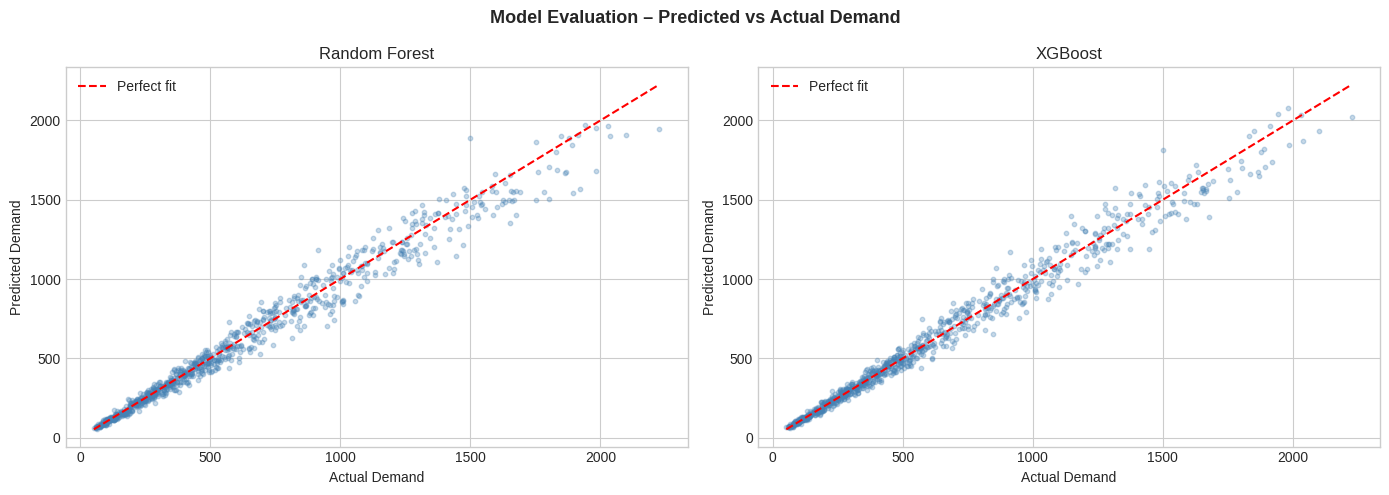

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation – Predicted vs Actual Demand', fontsize=13, fontweight='bold')

for ax, name, preds in zip(axes, ['Random Forest', 'XGBoost'], [rf_preds, xgb_preds]):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Demand')
    ax.set_ylabel('Predicted Demand')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

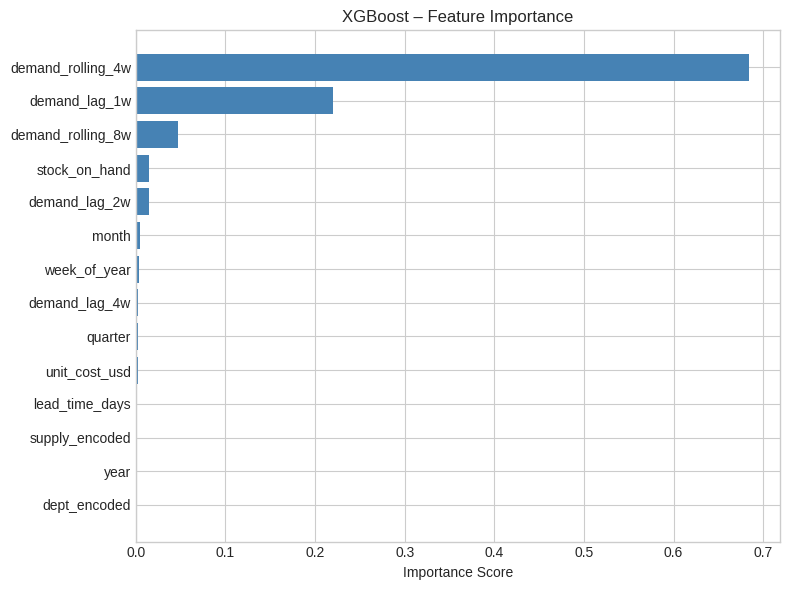

In [10]:
# Feature importance (XGBoost)
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('XGBoost – Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Actionable Inventory Insights

We translate model predictions into practical recommendations:  
which items are at risk of stockout or over-ordering in the next week.

In [11]:
# Use the most recent week of test data for recommendations
latest = test[test['date'] == test['date'].max()].copy()
latest['predicted_demand'] = xgb_model.predict(latest[FEATURES]).astype(int)
latest['department'] = le_dept.inverse_transform(latest['dept_encoded'])
latest['supply_item'] = le_supply.inverse_transform(latest['supply_encoded'])

# Flag stockout risk: stock on hand < 90% of predicted demand
latest['stockout_risk'] = latest['stock_on_hand'] < latest['predicted_demand'] * 0.9

# Flag overstock risk: stock on hand > 140% of predicted demand
latest['overstock_risk'] = latest['stock_on_hand'] > latest['predicted_demand'] * 1.4

# Recommended order quantity (with 15% safety buffer)
latest['recommended_order'] = ((latest['predicted_demand'] * 1.15) - latest['stock_on_hand']).clip(lower=0).astype(int)

print('=== Stockout Risk Alerts ===')
stockout_alerts = latest[latest['stockout_risk']][['department','supply_item','stock_on_hand','predicted_demand','recommended_order']]
print(stockout_alerts.sort_values('recommended_order', ascending=False).to_string(index=False))

print('\n=== Overstock / Expiry Risk Alerts ===')
overstock_alerts = latest[latest['overstock_risk']][['department','supply_item','stock_on_hand','predicted_demand']]
print(overstock_alerts.to_string(index=False))

=== Stockout Risk Alerts ===
  department        supply_item  stock_on_hand  predicted_demand  recommended_order
          ER              Masks           1314              1694                634
          ER    Surgical Gloves           1206              1476                491
     Surgery    Surgical Gloves           1352              1503                376
    Oncology           Syringes            791               913                258
     Surgery            IV Bags            423               570                232
General Ward           Syringes            596               691                198
    Oncology           Bandages            516               598                171
    Oncology        Blood Tubes            301               380                135
  Pediatrics           Bandages            374               429                119
General Ward          Catheters            143               181                 65
          ER Ventilator Filters            100 

In [12]:
# Summary dashboard
print('=== Weekly Supply Chain Summary ===')
print(f"Week of: {latest['date'].iloc[0].date()}")
print(f"Total predicted demand (all items/depts): {latest['predicted_demand'].sum():,} units")
print(f"Items at stockout risk: {latest['stockout_risk'].sum()}")
print(f"Items at overstock risk: {latest['overstock_risk'].sum()}")
print(f"Total recommended order volume: {latest['recommended_order'].sum():,} units")
est_cost = (latest['recommended_order'] * latest['unit_cost_usd']).sum()
print(f"Estimated order cost: ${est_cost:,.2f}")

=== Weekly Supply Chain Summary ===
Week of: 2023-12-24
Total predicted demand (all items/depts): 34,527 units
Items at stockout risk: 12
Items at overstock risk: 3
Total recommended order volume: 4,225 units
Estimated order cost: $95,353.57


## 8. Summary & Next Steps

### Results
- XGBoost outperformed Random Forest on MAPE, making it the production-ready model choice
- Lag features (especially 1-week and 4-week rolling average) were the most predictive signals
- The pipeline successfully identifies stockout and overstock risks before they occur

### Potential Improvements
- **Real data integration:** Connect to hospital ERP/EHR systems via API
- **LSTM/temporal models:** Deep learning approaches for longer-horizon forecasting
- **Hyperparameter tuning:** Grid search or Bayesian optimization for XGBoost
- **Automated retraining:** Schedule weekly model updates as new data arrives
- **Cost optimization:** Add budget constraints to the recommendation engine